# Football Match Probability Prediction

End-to-end notebook for predicting `home`, `draw`, and `away` probabilities from the provided football dataset. The main metric is multiclass log-loss, so every model is trained and ensembled as a probability estimator rather than a hard-label classifier.

Outputs:
- `dataset/submission.csv`
- `dataset/feature_importance_lgb.csv`

## 0.1 Full Dependency Install - macOS/Linux

Run this cell before everything else if you are using macOS or Linux. On macOS, LightGBM also needs the native `libomp` library, so this cell tries to install it with Homebrew when available.


In [ ]:
# Full dependency install cell for macOS/Linux. Run this before all other code cells.
import platform
import shutil
import subprocess
import sys

PIP_PACKAGES = [
    "numpy",
    "pandas",
    "scikit-learn",
    "lightgbm",
    "catboost",
    "optuna",
    "matplotlib",
    "jupyter",
    "ipykernel",
]

if platform.system() == "Darwin":
    if shutil.which("brew"):
        print("macOS detected. Installing/updating libomp for LightGBM...")
        subprocess.run(["brew", "install", "libomp"], check=False)
    else:
        print("macOS detected, but Homebrew was not found.")
        print("If LightGBM fails, install Homebrew, then run: brew install libomp")

print("Installing/upgrading Python packages...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", *PIP_PACKAGES])

print("\nInstall step complete.")
print("Important: if LightGBM or libomp was just installed, restart the notebook kernel, then run from the next cell downward.")


## 0.2 Full Dependency Install - Windows

Run this cell instead of `0.1` if you are using Windows. It installs the required Python packages into the current notebook kernel environment.


In [ ]:
# Full dependency install cell for Windows. Run this before all other code cells on Windows.
import platform
import subprocess
import sys

if platform.system() != "Windows":
    print("This cell is intended for Windows. If you are on macOS/Linux, use cell 0.1 instead.")

PIP_PACKAGES = [
    "numpy",
    "pandas",
    "scikit-learn",
    "lightgbm",
    "catboost",
    "optuna",
    "matplotlib",
    "jupyter",
    "ipykernel",
]

print("Installing/upgrading Python packages for Windows...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", *PIP_PACKAGES])

print("\nInstall step complete.")
print("Important: restart the notebook kernel, then run from the next cell downward.")


## 1. Package Setup

Run this cell first. It installs missing modeling dependencies when the notebook environment does not already provide them.

In [1]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "lightgbm": "lightgbm",
    "catboost": "catboost",
    "optuna": "optuna",
    "matplotlib": "matplotlib",
}

missing_packages = [pip_name for import_name, pip_name in REQUIRED_PACKAGES.items() if importlib.util.find_spec(import_name) is None]
if missing_packages:
    print("Installing missing packages:", missing_packages)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("All required packages are already installed.")

Installing missing packages: ['numpy', 'pandas', 'scikit-learn', 'lightgbm', 'catboost', 'optuna', 'matplotlib']
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 10.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 11.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 11.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 11.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.9/28.9 MB 1.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


## 2. Imports & Configuration

In [5]:
from pathlib import Path
import gc
import json
import math
import platform
import shutil
import warnings

import numpy as np
import pandas as pd
from sklearn.metrics import log_loss
from sklearn.model_selection import StratifiedKFold, train_test_split

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

try:
    import lightgbm as lgb
    from lightgbm import LGBMClassifier
except Exception as exc:
    if platform.system() == "Darwin" and isinstance(exc, OSError):
        brew_hint = "brew install libomp" if shutil.which("brew") else "Install Homebrew first, then run: brew install libomp"
        raise ImportError(
            "LightGBM is installed but macOS cannot load its native OpenMP library.\n"
            "Fix in Terminal, then restart the notebook kernel and run again:\n"
            f"  {brew_hint}\n"
            "  python3 -m pip install --upgrade --force-reinstall lightgbm\n"
            "If you use a virtual environment, run the pip command with that environment's python."
        ) from exc
    raise ImportError("LightGBM is required for the primary model. Re-run the package setup cell or install lightgbm manually.") from exc

try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except Exception as exc:
    CATBOOST_AVAILABLE = False
    print("CatBoost unavailable; the notebook will continue with LightGBM only.", repr(exc))

DATA_DIR = Path("dataset")
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
OUTPUT_EXAMPLE_PATH = DATA_DIR / "output_example.csv"
SUBMISSION_PATH = DATA_DIR / "submission.csv"
FEATURE_IMPORTANCE_PATH = DATA_DIR / "feature_importance_lgb.csv"

RANDOM_STATE = 42
N_SPLITS = 5
CLASS_ORDER = ["home", "draw", "away"]
TARGET_MAP = {label: idx for idx, label in enumerate(CLASS_ORDER)}
EPS = 1e-15

DEBUG_SAMPLE = False
DEBUG_SAMPLE_SIZE = 20000
RUN_CATBOOST = True
RUN_TIME_HOLDOUT = True
RUN_OPTUNA = False

print("Config ready")

Config ready


## 3. Helper Functions

In [6]:
def safe_to_datetime(series):
    return pd.to_datetime(series, errors="coerce")


def safe_bool_to_float(series):
    mapping = {
        True: 1.0,
        False: 0.0,
        "true": 1.0,
        "false": 0.0,
        "True": 1.0,
        "False": 0.0,
        "TRUE": 1.0,
        "FALSE": 0.0,
        "1": 1.0,
        "0": 0.0,
        1: 1.0,
        0: 0.0,
        1.0: 1.0,
        0.0: 0.0,
    }
    return series.map(mapping).astype("float32")


def normalize_probabilities(pred, eps=EPS):
    pred = np.asarray(pred, dtype="float64")
    pred = np.nan_to_num(pred, nan=1.0 / len(CLASS_ORDER), posinf=1.0 - eps, neginf=eps)
    pred = np.clip(pred, eps, 1.0 - eps)
    pred = pred / pred.sum(axis=1, keepdims=True)
    return pred


def validate_input_files(train, test, output_example):
    for name, df in [("train", train), ("test", test), ("output_example", output_example)]:
        assert "id" in df.columns, f"Missing id column in {name}"
        assert df["id"].duplicated().sum() == 0, f"Duplicate id values in {name}"
    assert "target" in train.columns, "Missing target column in train"
    assert set(train["target"].dropna().unique()).issubset(set(CLASS_ORDER)), "Unexpected target labels"
    assert list(output_example.columns) == ["id", "home", "draw", "away"], "output_example.csv must have columns id,home,draw,away"
    assert len(test) == len(output_example), "test and output_example row counts differ"
    if not test["id"].equals(output_example["id"]):
        print("Warning: test id order differs from output_example; final submission will be aligned to output_example.")


def validate_submission(submission, output_example):
    assert list(submission.columns) == ["id", "home", "draw", "away"]
    assert submission.shape[0] == output_example.shape[0]
    assert submission["id"].equals(output_example["id"])
    probs = submission[["home", "draw", "away"]].to_numpy(dtype="float64")
    assert np.isfinite(probs).all(), "Submission contains NaN or inf"
    assert (probs >= 0).all() and (probs <= 1).all(), "Submission probabilities are outside [0, 1]"
    assert np.allclose(probs.sum(axis=1), 1.0, atol=1e-8), "Submission rows do not sum to 1"


def window_cols(side, attribute, window):
    return [f"{side}_team_history_{attribute}_{idx}" for idx in range(1, window + 1)]


def rowwise_nanmean(frame):
    return frame.mean(axis=1, skipna=True).astype("float32")


def rowwise_nansum(frame):
    return frame.sum(axis=1, skipna=True).astype("float32")


def make_team_history_features(df, side):
    assert side in ["home", "away"]
    out = pd.DataFrame(index=df.index)
    prefix = f"{side}_team_history"
    current_date = df["match_date_dt"]
    current_league = df["league_id"]
    current_coach = df[f"{side}_team_coach_id"]

    goals = df[window_cols(side, "goal", 10)].apply(pd.to_numeric, errors="coerce")
    opp_goals = df[window_cols(side, "opponent_goal", 10)].apply(pd.to_numeric, errors="coerce")
    ratings = df[window_cols(side, "rating", 10)].apply(pd.to_numeric, errors="coerce")
    opp_ratings = df[window_cols(side, "opponent_rating", 10)].apply(pd.to_numeric, errors="coerce")
    is_play_home = df[window_cols(side, "is_play_home", 10)].apply(safe_bool_to_float)
    is_cup_hist = df[window_cols(side, "is_cup", 10)].apply(safe_bool_to_float)
    league_hist = df[window_cols(side, "league_id", 10)].apply(pd.to_numeric, errors="coerce")
    coach_hist = df[window_cols(side, "coach", 10)]

    goal_diff = goals.to_numpy(dtype="float64") - opp_goals.to_numpy(dtype="float64")
    goal_diff = pd.DataFrame(goal_diff, index=df.index, columns=[f"gd_{i}" for i in range(1, 11)])
    win = (goal_diff > 0).astype("float32").where(goal_diff.notna())
    draw = (goal_diff == 0).astype("float32").where(goal_diff.notna())
    loss = (goal_diff < 0).astype("float32").where(goal_diff.notna())
    points = (win * 3.0 + draw).astype("float32")
    rating_diff = pd.DataFrame(ratings.to_numpy(dtype="float64") - opp_ratings.to_numpy(dtype="float64"), index=df.index)

    out[f"{side}_history_available_count_goal"] = goals.notna().sum(axis=1).astype("float32")
    out[f"{side}_history_available_count_rating"] = ratings.notna().sum(axis=1).astype("float32")
    out[f"{side}_history_available_count_coach"] = coach_hist.notna().sum(axis=1).astype("float32")
    out[f"{side}_missing_history_rate_goal"] = 1.0 - out[f"{side}_history_available_count_goal"] / 10.0
    out[f"{side}_missing_history_rate_rating"] = 1.0 - out[f"{side}_history_available_count_rating"] / 10.0

    for window in [3, 5, 10]:
        idx = list(range(window))
        out[f"{side}_points_sum_{window}"] = rowwise_nansum(points.iloc[:, idx])
        out[f"{side}_points_avg_{window}"] = rowwise_nanmean(points.iloc[:, idx])
        out[f"{side}_win_rate_{window}"] = rowwise_nanmean(win.iloc[:, idx])
        out[f"{side}_draw_rate_{window}"] = rowwise_nanmean(draw.iloc[:, idx])
        out[f"{side}_loss_rate_{window}"] = rowwise_nanmean(loss.iloc[:, idx])
        out[f"{side}_goals_avg_{window}"] = rowwise_nanmean(goals.iloc[:, idx])
        out[f"{side}_opp_goals_avg_{window}"] = rowwise_nanmean(opp_goals.iloc[:, idx])
        out[f"{side}_goal_diff_avg_{window}"] = rowwise_nanmean(goal_diff.iloc[:, idx])
        out[f"{side}_rating_avg_{window}"] = rowwise_nanmean(ratings.iloc[:, idx])
        out[f"{side}_opp_rating_avg_{window}"] = rowwise_nanmean(opp_ratings.iloc[:, idx])
        out[f"{side}_rating_diff_avg_{window}"] = rowwise_nanmean(rating_diff.iloc[:, idx])
        out[f"{side}_played_home_rate_{window}"] = rowwise_nanmean(is_play_home.iloc[:, idx])
        out[f"{side}_cup_match_rate_{window}"] = rowwise_nanmean(is_cup_hist.iloc[:, idx])
        same_league = league_hist.iloc[:, idx].eq(current_league, axis=0).where(league_hist.iloc[:, idx].notna())
        out[f"{side}_same_league_rate_{window}"] = same_league.mean(axis=1, skipna=True).astype("float32")

    out[f"{side}_goal_diff_sum_10"] = rowwise_nansum(goal_diff)
    out[f"{side}_goals_std_10"] = goals.std(axis=1, skipna=True).astype("float32")
    out[f"{side}_opp_goals_std_10"] = opp_goals.std(axis=1, skipna=True).astype("float32")
    out[f"{side}_rating_diff_std_10"] = rating_diff.std(axis=1, skipna=True).astype("float32")
    out[f"{side}_rating_diff_min_10"] = rating_diff.min(axis=1, skipna=True).astype("float32")
    out[f"{side}_rating_diff_max_10"] = rating_diff.max(axis=1, skipna=True).astype("float32")

    out[f"{side}_points_trend_3_vs_10"] = out[f"{side}_points_avg_3"] - out[f"{side}_points_avg_10"]
    out[f"{side}_goals_trend_3_vs_10"] = out[f"{side}_goals_avg_3"] - out[f"{side}_goals_avg_10"]
    out[f"{side}_defense_trend_3_vs_10"] = out[f"{side}_opp_goals_avg_3"] - out[f"{side}_opp_goals_avg_10"]
    out[f"{side}_rating_trend_3_vs_10"] = out[f"{side}_rating_avg_3"] - out[f"{side}_rating_avg_10"]

    match_date_cols = window_cols(side, "match_date", 10)
    rest_days = pd.DataFrame(index=df.index)
    future_flags = []
    for idx, col in enumerate(match_date_cols, start=1):
        history_date = safe_to_datetime(df[col])
        days_since = (current_date - history_date).dt.days.astype("float32")
        future_flag = days_since < 0
        future_flags.append(future_flag)
        days_since = days_since.mask(future_flag)
        rest_days[f"days_{idx}"] = days_since
        out[f"{side}_days_since_last_match_{idx}"] = days_since
    out[f"{side}_has_future_history_flag"] = np.column_stack(future_flags).any(axis=1).astype("float32")
    out[f"{side}_avg_rest_days_3"] = rowwise_nanmean(rest_days.iloc[:, :3])
    out[f"{side}_avg_rest_days_5"] = rowwise_nanmean(rest_days.iloc[:, :5])
    out[f"{side}_avg_rest_days_10"] = rowwise_nanmean(rest_days.iloc[:, :10])
    out[f"{side}_min_rest_days_10"] = rest_days.min(axis=1, skipna=True).astype("float32")
    out[f"{side}_max_rest_days_10"] = rest_days.max(axis=1, skipna=True).astype("float32")
    out[f"{side}_std_rest_days_10"] = rest_days.std(axis=1, skipna=True).astype("float32")

    home_masked_points = points.where(is_play_home == 1.0)
    away_masked_points = points.where(is_play_home == 0.0)
    home_masked_goals = goals.where(is_play_home == 1.0)
    away_masked_goals = goals.where(is_play_home == 0.0)
    out[f"{side}_points_when_play_home_avg_10"] = rowwise_nanmean(home_masked_points)
    out[f"{side}_points_when_play_away_avg_10"] = rowwise_nanmean(away_masked_points)
    out[f"{side}_goals_when_play_home_avg_10"] = rowwise_nanmean(home_masked_goals)
    out[f"{side}_goals_when_play_away_avg_10"] = rowwise_nanmean(away_masked_goals)

    same_coach = coach_hist.eq(current_coach, axis=0).where(coach_hist.notna())
    out[f"{side}_same_coach_rate_10"] = same_coach.mean(axis=1, skipna=True).astype("float32")
    out[f"{side}_coach_change_flag"] = (out[f"{side}_same_coach_rate_10"] < 1.0).astype("float32")
    out[f"{side}_coach_unique_count_10"] = coach_hist.nunique(axis=1, dropna=True).astype("float32")

    league_change = league_hist.ne(league_hist.shift(axis=1)) & league_hist.notna() & league_hist.shift(axis=1).notna()
    out[f"{side}_league_switch_count_10"] = league_change.sum(axis=1).astype("float32")
    return out


def make_relative_features(features):
    out = pd.DataFrame(index=features.index)
    for base in [
        "points_avg_3", "points_avg_5", "points_avg_10",
        "goals_avg_3", "goals_avg_5", "goals_avg_10",
        "opp_goals_avg_3", "opp_goals_avg_5", "opp_goals_avg_10",
        "goal_diff_avg_3", "goal_diff_avg_5", "goal_diff_avg_10",
        "rating_avg_3", "rating_avg_5", "rating_avg_10",
        "rating_diff_avg_3", "rating_diff_avg_5", "rating_diff_avg_10",
        "avg_rest_days_3", "avg_rest_days_5", "avg_rest_days_10",
        "same_coach_rate_10", "same_league_rate_10",
    ]:
        home_col = f"home_{base}"
        away_col = f"away_{base}"
        if home_col in features.columns and away_col in features.columns:
            out[f"diff_{base}"] = features[home_col] - features[away_col]

    out["home_relevant_venue_points_avg_10"] = features["home_points_when_play_home_avg_10"]
    out["away_relevant_venue_points_avg_10"] = features["away_points_when_play_away_avg_10"]
    out["venue_form_diff"] = out["home_relevant_venue_points_avg_10"] - out["away_relevant_venue_points_avg_10"]
    out["coach_stability_diff"] = features["home_same_coach_rate_10"] - features["away_same_coach_rate_10"]
    out["rest_days_diff_1"] = features["home_days_since_last_match_1"] - features["away_days_since_last_match_1"]
    return out


def build_tabular_features(train, test):
    train_work = train.copy()
    test_work = test.copy()
    train_work["__is_train"] = 1
    test_work["__is_train"] = 0
    full = pd.concat([train_work, test_work], axis=0, ignore_index=True, sort=False)

    full["match_date_dt"] = safe_to_datetime(full["match_date"])
    full["match_year"] = full["match_date_dt"].dt.year.astype("float32")
    full["match_month"] = full["match_date_dt"].dt.month.astype("float32")
    full["match_day"] = full["match_date_dt"].dt.day.astype("float32")
    full["match_dayofweek"] = full["match_date_dt"].dt.dayofweek.astype("float32")
    full["match_weekofyear"] = full["match_date_dt"].dt.isocalendar().week.astype("float32")
    full["match_is_weekend"] = full["match_dayofweek"].isin([5, 6]).astype("float32")
    full["month_sin"] = np.sin(2 * np.pi * full["match_month"] / 12).astype("float32")
    full["month_cos"] = np.cos(2 * np.pi * full["match_month"] / 12).astype("float32")
    full["dow_sin"] = np.sin(2 * np.pi * full["match_dayofweek"] / 7).astype("float32")
    full["dow_cos"] = np.cos(2 * np.pi * full["match_dayofweek"] / 7).astype("float32")
    full["is_cup_clean"] = safe_bool_to_float(full["is_cup"])
    full["home_coach_missing"] = full["home_team_coach_id"].isna().astype("float32")
    full["away_coach_missing"] = full["away_team_coach_id"].isna().astype("float32")

    history_features = pd.concat([
        make_team_history_features(full, "home"),
        make_team_history_features(full, "away"),
    ], axis=1)
    relative_features = make_relative_features(history_features)
    full = pd.concat([full, history_features, relative_features], axis=1)

    leakage_or_raw_cols = ["id", "target", "score", "match_date", "match_date_dt", "is_cup", "__is_train"]
    raw_team_name_cols = ["home_team_name", "away_team_name"]
    raw_history_date_cols = [col for col in full.columns if col.endswith(tuple(str(i) for i in range(1, 11))) and "history_match_date" in col]
    drop_cols = [col for col in leakage_or_raw_cols + raw_team_name_cols + raw_history_date_cols if col in full.columns]

    feature_full = full.drop(columns=drop_cols)
    feature_full = feature_full.replace([np.inf, -np.inf], np.nan)

    categorical_candidates = [
        "league_id", "league_name", "home_team_coach_id", "away_team_coach_id",
    ]
    categorical_candidates += [col for col in feature_full.columns if "history_coach_" in col or "history_league_id_" in col]
    categorical_cols = [col for col in categorical_candidates if col in feature_full.columns]

    for col in feature_full.columns:
        if col in categorical_cols:
            feature_full[col] = feature_full[col].astype("string").fillna("__MISSING__").astype("category")
        elif feature_full[col].dtype == "object":
            converted = pd.to_numeric(feature_full[col], errors="coerce")
            if converted.notna().sum() > 0:
                feature_full[col] = converted.astype("float32")
            else:
                feature_full[col] = feature_full[col].astype("string").fillna("__MISSING__").astype("category")
                categorical_cols.append(col)
        elif str(feature_full[col].dtype) == "boolean":
            feature_full[col] = feature_full[col].astype("float32")

    train_mask = full["__is_train"].eq(1).to_numpy()
    X_train = feature_full.loc[train_mask].reset_index(drop=True)
    X_test = feature_full.loc[~train_mask].reset_index(drop=True)
    X_train, X_test = X_train.align(X_test, join="left", axis=1)
    assert list(X_train.columns) == list(X_test.columns)
    categorical_cols = [col for col in categorical_cols if col in X_train.columns]
    return X_train, X_test, categorical_cols


def make_catboost_frame(frame, categorical_cols):
    out = frame.copy()
    for col in categorical_cols:
        out[col] = out[col].astype("string").fillna("__MISSING__").astype(str)
    return out


def optimize_ensemble_weights(oof_predictions, y, model_names):
    n_models = len(oof_predictions)
    if n_models == 1:
        return np.array([1.0]), log_loss(y, normalize_probabilities(oof_predictions[0]), labels=[0, 1, 2])

    best_weights = np.ones(n_models) / n_models
    best_score = log_loss(y, normalize_probabilities(sum(w * p for w, p in zip(best_weights, oof_predictions))), labels=[0, 1, 2])

    if n_models == 2:
        for w0 in np.linspace(0, 1, 101):
            weights = np.array([w0, 1 - w0])
            pred = normalize_probabilities(weights[0] * oof_predictions[0] + weights[1] * oof_predictions[1])
            score = log_loss(y, pred, labels=[0, 1, 2])
            if score < best_score:
                best_score = score
                best_weights = weights
    else:
        rng = np.random.default_rng(RANDOM_STATE)
        for _ in range(3000):
            weights = rng.dirichlet(np.ones(n_models))
            pred = normalize_probabilities(sum(w * p for w, p in zip(weights, oof_predictions)))
            score = log_loss(y, pred, labels=[0, 1, 2])
            if score < best_score:
                best_score = score
                best_weights = weights

    print("Best ensemble weights:")
    for name, weight in zip(model_names, best_weights):
        print(f"  {name}: {weight:.4f}")
    return best_weights, best_score

## 4. Load Data & Validate

In [7]:
train = pd.read_csv(TRAIN_PATH, low_memory=False)
test = pd.read_csv(TEST_PATH, low_memory=False)
output_example = pd.read_csv(OUTPUT_EXAMPLE_PATH, low_memory=False)

validate_input_files(train, test, output_example)

if DEBUG_SAMPLE:
    train = train.sample(n=min(DEBUG_SAMPLE_SIZE, len(train)), random_state=RANDOM_STATE).sort_values("match_date").reset_index(drop=True)
    print(f"DEBUG_SAMPLE enabled: train reduced to {len(train):,} rows")

train["match_date_dt"] = safe_to_datetime(train["match_date"])
test["match_date_dt"] = safe_to_datetime(test["match_date"])
y = train["target"].map(TARGET_MAP).astype("int64")
assert y.notna().all()

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Output example shape:", output_example.shape)
print("\nTarget distribution:")
display(train["target"].value_counts().to_frame("count").assign(percent=lambda d: 100 * d["count"] / d["count"].sum()))
print("\nMissing rate top train columns:")
display((train.isna().mean().sort_values(ascending=False).head(20) * 100).round(2).to_frame("missing_%"))
print("\nDate ranges:")
print("Train:", train["match_date_dt"].min(), "->", train["match_date_dt"].max())
print("Test :", test["match_date_dt"].min(), "->", test["match_date_dt"].max())
print("Test id order equals output_example:", test["id"].equals(output_example["id"]))

Train shape: (144290, 192)
Test shape: (72711, 190)
Output example shape: (72711, 4)

Target distribution:


,count,percent
target,,
home,62616,43.395939
away,45306,31.399265
draw,36368,25.204796



Missing rate top train columns:


,missing_%
away_team_history_coach_10,40.85
home_team_history_coach_10,40.53
away_team_history_coach_9,40.27
home_team_history_coach_9,40.00
away_team_history_coach_8,39.74
home_team_history_coach_8,39.50
away_team_history_coach_7,39.26
home_team_history_coach_7,39.00
away_team_history_coach_6,38.78
home_team_history_coach_6,38.60



Date ranges:
Train: 2019-12-01 00:45:00 -> 2021-07-31 00:00:00
Test : 2021-05-01 00:15:00 -> 2021-11-30 23:30:00
Test id order equals output_example: True


## 5. Build Tabular Features

In [8]:
X_train, X_test, categorical_cols = build_tabular_features(train.drop(columns=["match_date_dt"]), test.drop(columns=["match_date_dt"]))

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Number of categorical columns:", len(categorical_cols))
print("First categorical columns:", categorical_cols[:20])
assert list(X_train.columns) == list(X_test.columns)
assert "target" not in X_train.columns and "score" not in X_train.columns
assert "home_team_name" not in X_train.columns and "away_team_name" not in X_train.columns

gc.collect()

X_train shape: (144290, 369)
X_test shape: (72711, 369)
Number of categorical columns: 44
First categorical columns: ['league_id', 'league_name', 'home_team_coach_id', 'away_team_coach_id', 'home_team_history_coach_1', 'home_team_history_coach_2', 'home_team_history_coach_3', 'home_team_history_coach_4', 'home_team_history_coach_5', 'home_team_history_coach_6', 'home_team_history_coach_7', 'home_team_history_coach_8', 'home_team_history_coach_9', 'home_team_history_coach_10', 'home_team_history_league_id_1', 'home_team_history_league_id_2', 'home_team_history_league_id_3', 'home_team_history_league_id_4', 'home_team_history_league_id_5', 'home_team_history_league_id_6']


0

## 6. LightGBM OOF Training

In [9]:
def train_lightgbm_cv(X_train, y, X_test, categorical_cols):
    params = {
        "objective": "multiclass",
        "num_class": 3,
        "metric": "multi_logloss",
        "learning_rate": 0.03,
        "num_leaves": 63,
        "max_depth": -1,
        "min_child_samples": 50,
        "subsample": 0.85,
        "subsample_freq": 1,
        "colsample_bytree": 0.85,
        "reg_alpha": 0.1,
        "reg_lambda": 1.0,
        "n_estimators": 5000,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": -1,
    }

    folds = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    oof = np.zeros((len(X_train), 3), dtype="float64")
    test_pred = np.zeros((len(X_test), 3), dtype="float64")
    fold_scores = []
    importances = []

    for fold, (tr_idx, va_idx) in enumerate(folds.split(X_train, y), start=1):
        print(f"\nLightGBM fold {fold}/{N_SPLITS}")
        model = LGBMClassifier(**params)
        model.fit(
            X_train.iloc[tr_idx], y.iloc[tr_idx],
            eval_set=[(X_train.iloc[va_idx], y.iloc[va_idx])],
            eval_metric="multi_logloss",
            categorical_feature=categorical_cols,
            callbacks=[lgb.early_stopping(200), lgb.log_evaluation(200)],
        )
        valid_pred = normalize_probabilities(model.predict_proba(X_train.iloc[va_idx]))
        oof[va_idx] = valid_pred
        fold_score = log_loss(y.iloc[va_idx], valid_pred, labels=[0, 1, 2])
        fold_scores.append(fold_score)
        print(f"Fold {fold} log-loss: {fold_score:.6f}")

        test_pred += normalize_probabilities(model.predict_proba(X_test)) / N_SPLITS
        importances.append(pd.DataFrame({"feature": X_train.columns, "importance": model.feature_importances_, "fold": fold}))
        del model
        gc.collect()

    oof = normalize_probabilities(oof)
    test_pred = normalize_probabilities(test_pred)
    oof_score = log_loss(y, oof, labels=[0, 1, 2])
    fi = pd.concat(importances, axis=0).groupby("feature", as_index=False)["importance"].mean().sort_values("importance", ascending=False)
    fi.to_csv(FEATURE_IMPORTANCE_PATH, index=False)

    print("\nLightGBM fold scores:", [round(s, 6) for s in fold_scores])
    print(f"LightGBM OOF log-loss: {oof_score:.6f}")
    print(f"Feature importance saved to: {FEATURE_IMPORTANCE_PATH}")
    display(fi.head(50))
    return oof, test_pred, fold_scores, fi


oof_lgb, test_lgb, lgb_fold_scores, lgb_feature_importance = train_lightgbm_cv(X_train, y, X_test, categorical_cols)


LightGBM fold 1/5
Training until validation scores don't improve for 200 rounds
[200]	valid_0's multi_logloss: 1.05242
Early stopping, best iteration is:
[58]	valid_0's multi_logloss: 1.02309
Fold 1 log-loss: 1.023089

LightGBM fold 2/5
Training until validation scores don't improve for 200 rounds
[200]	valid_0's multi_logloss: 1.05191
Early stopping, best iteration is:
[58]	valid_0's multi_logloss: 1.02399
Fold 2 log-loss: 1.023987

LightGBM fold 3/5
Training until validation scores don't improve for 200 rounds
[200]	valid_0's multi_logloss: 1.04993
Early stopping, best iteration is:
[57]	valid_0's multi_logloss: 1.02291
Fold 3 log-loss: 1.022912

LightGBM fold 4/5
Training until validation scores don't improve for 200 rounds
[200]	valid_0's multi_logloss: 1.0522
Early stopping, best iteration is:
[58]	valid_0's multi_logloss: 1.02251
Fold 4 log-loss: 1.022512

LightGBM fold 5/5
Training until validation scores don't improve for 200 rounds
[200]	valid_0's multi_logloss: 1.05222
Early

,feature,importance
357,league_id,428.0
314,home_team_history_league_id_10,408.6
123,away_team_history_league_id_10,399.8
122,away_team_history_league_id_1,366.4
322,home_team_history_league_id_9,361.2
131,away_team_history_league_id_9,331.2
315,home_team_history_league_id_2,328.2
313,home_team_history_league_id_1,322.8
317,home_team_history_league_id_4,320.4
124,away_team_history_league_id_2,305.2


## 7. CatBoost OOF Training

In [14]:
def train_catboost_cv(X_train, y, X_test, categorical_cols):
    X_train_cb = make_catboost_frame(X_train, categorical_cols)
    X_test_cb = make_catboost_frame(X_test, categorical_cols)
    cat_feature_indices = [X_train_cb.columns.get_loc(col) for col in categorical_cols]

    params = {
        "loss_function": "MultiClass",
        "eval_metric": "MultiClass",
        "iterations": 5000,
        "learning_rate": 0.03,
        "depth": 6,
        "l2_leaf_reg": 5,
        "random_seed": RANDOM_STATE,
        "verbose": 200,
        "early_stopping_rounds": 200,
        "allow_writing_files": False,
    }

    folds = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    oof = np.zeros((len(X_train_cb), 3), dtype="float64")
    test_pred = np.zeros((len(X_test_cb), 3), dtype="float64")
    fold_scores = []

    for fold, (tr_idx, va_idx) in enumerate(folds.split(X_train_cb, y), start=1):
        print(f"\nCatBoost fold {fold}/{N_SPLITS}")
        model = CatBoostClassifier(**params)
        model.fit(
            X_train_cb.iloc[tr_idx], y.iloc[tr_idx],
            eval_set=(X_train_cb.iloc[va_idx], y.iloc[va_idx]),
            cat_features=cat_feature_indices,
            use_best_model=True,
        )
        valid_pred = normalize_probabilities(model.predict_proba(X_train_cb.iloc[va_idx]))
        oof[va_idx] = valid_pred
        fold_score = log_loss(y.iloc[va_idx], valid_pred, labels=[0, 1, 2])
        fold_scores.append(fold_score)
        print(f"Fold {fold} log-loss: {fold_score:.6f}")
        test_pred += normalize_probabilities(model.predict_proba(X_test_cb)) / N_SPLITS
        del model
        gc.collect()

    oof = normalize_probabilities(oof)
    test_pred = normalize_probabilities(test_pred)
    oof_score = log_loss(y, oof, labels=[0, 1, 2])
    print("\nCatBoost fold scores:", [round(s, 6) for s in fold_scores])
    print(f"CatBoost OOF log-loss: {oof_score:.6f}")
    return oof, test_pred, fold_scores


if RUN_CATBOOST and CATBOOST_AVAILABLE:
    oof_cat, test_cat, cat_fold_scores = train_catboost_cv(X_train, y, X_test, categorical_cols)
else:
    oof_cat, test_cat, cat_fold_scores = None, None, None
    print("Skipping CatBoost.")


CatBoost fold 1/5
0:	learn: 1.0948093	test: 1.0948730	best: 1.0948730 (0)	total: 465ms	remaining: 38m 42s
200:	learn: 1.0104896	test: 1.0132391	best: 1.0132391 (200)	total: 1m 6s	remaining: 26m 19s
400:	learn: 1.0025409	test: 1.0097007	best: 1.0097007 (400)	total: 2m 15s	remaining: 25m 54s
600:	learn: 0.9951712	test: 1.0077166	best: 1.0077166 (600)	total: 3m 25s	remaining: 25m
800:	learn: 0.9888490	test: 1.0066746	best: 1.0066746 (800)	total: 4m 34s	remaining: 24m 1s
1000:	learn: 0.9831243	test: 1.0060870	best: 1.0060812 (997)	total: 5m 46s	remaining: 23m 4s
1200:	learn: 0.9780771	test: 1.0055877	best: 1.0055874 (1199)	total: 6m 59s	remaining: 22m 6s
1400:	learn: 0.9731318	test: 1.0051325	best: 1.0051189 (1396)	total: 8m 10s	remaining: 21m
1600:	learn: 0.9684583	test: 1.0048906	best: 1.0048906 (1600)	total: 9m 24s	remaining: 19m 58s
1800:	learn: 0.9636393	test: 1.0047301	best: 1.0047102 (1790)	total: 10m 36s	remaining: 18m 50s
2000:	learn: 0.9590623	test: 1.0046104	best: 1.0045838 (19

## 8. Diagnostic Time Holdout

This is a sanity check only. The main model selection uses stratified OOF predictions because the test period is not simply after all training rows.

In [15]:
if RUN_TIME_HOLDOUT:
    date_values = train["match_date_dt"]
    cutoff = date_values.quantile(0.8)
    tr_mask = date_values < cutoff
    va_mask = date_values >= cutoff
    print("Time holdout cutoff:", cutoff)
    print("Train rows:", int(tr_mask.sum()), "Validation rows:", int(va_mask.sum()))

    time_model = LGBMClassifier(
        objective="multiclass",
        num_class=3,
        metric="multi_logloss",
        learning_rate=0.03,
        num_leaves=63,
        min_child_samples=50,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=1.0,
        n_estimators=5000,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )
    time_model.fit(
        X_train.loc[tr_mask], y.loc[tr_mask],
        eval_set=[(X_train.loc[va_mask], y.loc[va_mask])],
        eval_metric="multi_logloss",
        categorical_feature=categorical_cols,
        callbacks=[lgb.early_stopping(200), lgb.log_evaluation(200)],
    )
    time_pred = normalize_probabilities(time_model.predict_proba(X_train.loc[va_mask]))
    time_score = log_loss(y.loc[va_mask], time_pred, labels=[0, 1, 2])
    print(f"Time holdout LightGBM log-loss: {time_score:.6f}")
    del time_model
    gc.collect()
else:
    print("Skipping time holdout.")

Time holdout cutoff: 2021-02-20 19:45:00
Train rows: 88787 Validation rows: 22199
Training until validation scores don't improve for 200 rounds
[200]	valid_0's multi_logloss: 1.06856
Early stopping, best iteration is:
[49]	valid_0's multi_logloss: 1.02681
Time holdout LightGBM log-loss: 1.026806


## 9. Ensemble & Submission

In [16]:
# Build the ensemble from whichever model cells have successfully run.
# This keeps the notebook safe if CatBoost was skipped, failed, or not executed.
assert "oof_lgb" in globals() and "test_lgb" in globals(), "Run the LightGBM training cell before this ensemble cell."

oof_predictions = [oof_lgb]
test_predictions = [test_lgb]
model_names = ["LightGBM"]

oof_cat_safe = globals().get("oof_cat", None)
test_cat_safe = globals().get("test_cat", None)

if oof_cat_safe is not None and test_cat_safe is not None:
    candidate_score = log_loss(y, oof_cat_safe, labels=[0, 1, 2])
    print(f"CatBoost candidate OOF log-loss: {candidate_score:.6f}")
    oof_predictions.append(oof_cat_safe)
    test_predictions.append(test_cat_safe)
    model_names.append("CatBoost")
else:
    print("CatBoost predictions not found; continuing with LightGBM-only ensemble.")

weights, ensemble_oof_score = optimize_ensemble_weights(oof_predictions, y, model_names)
final_oof_pred = normalize_probabilities(sum(w * p for w, p in zip(weights, oof_predictions)))
final_test_pred = normalize_probabilities(sum(w * p for w, p in zip(weights, test_predictions)))

print(f"Final ensemble OOF log-loss: {ensemble_oof_score:.6f}")
print("OOF probability check:", final_oof_pred.min(), final_oof_pred.max(), final_oof_pred.sum(axis=1)[:5])

raw_submission = pd.DataFrame({
    "id": test["id"].values,
    "home": final_test_pred[:, 0],
    "draw": final_test_pred[:, 1],
    "away": final_test_pred[:, 2],
})

submission = output_example[["id"]].merge(raw_submission, on="id", how="left")
missing_submission_rows = submission[["home", "draw", "away"]].isna().any(axis=1).sum()
assert missing_submission_rows == 0, f"Submission has {missing_submission_rows} missing rows after id alignment"
submission[["home", "draw", "away"]] = normalize_probabilities(submission[["home", "draw", "away"]].to_numpy())
validate_submission(submission, output_example)
submission.to_csv(SUBMISSION_PATH, index=False)

print(f"Saved submission to: {SUBMISSION_PATH}")
display(submission.head())
display(submission[["home", "draw", "away"]].describe())

CatBoost candidate OOF log-loss: 1.005205
Best ensemble weights:
  LightGBM: 0.0600
  CatBoost: 0.9400
Final ensemble OOF log-loss: 1.005114
OOF probability check: 0.013034419664168611 0.9655153977946271 [1. 1. 1. 1. 1.]
Saved submission to: dataset/submission.csv


,id,home,draw,away
0,17761448,0.449930,0.300613,0.249457
1,17695487,0.359213,0.301614,0.339174
2,17715496,0.328772,0.298207,0.373021
3,17715493,0.162069,0.267169,0.570762
4,17715492,0.467268,0.294276,0.238456


,home,draw,away
count,72711.000000,72711.000000,72711.000000
mean,0.434970,0.239892,0.325138
std,0.159655,0.059858,0.150447
min,0.019917,0.034354,0.018099
25%,0.328291,0.200396,0.219920
50%,0.423665,0.245366,0.302504
75%,0.533046,0.284503,0.405272
max,0.946877,0.449219,0.931428


## 10. Output Quality Insights

This final section compares the model against simple baselines and visualizes whether the produced probabilities look calibrated and useful. It does not retrain any model.


,model,log_loss,improvement_vs_train_prior
0,Uniform 1/3,1.098612,-0.025260
1,Train prior,1.073352,0.000000
2,LightGBM OOF,1.022997,0.050355
3,CatBoost OOF,1.005205,0.068147
4,Final ensemble OOF,1.005114,0.068239


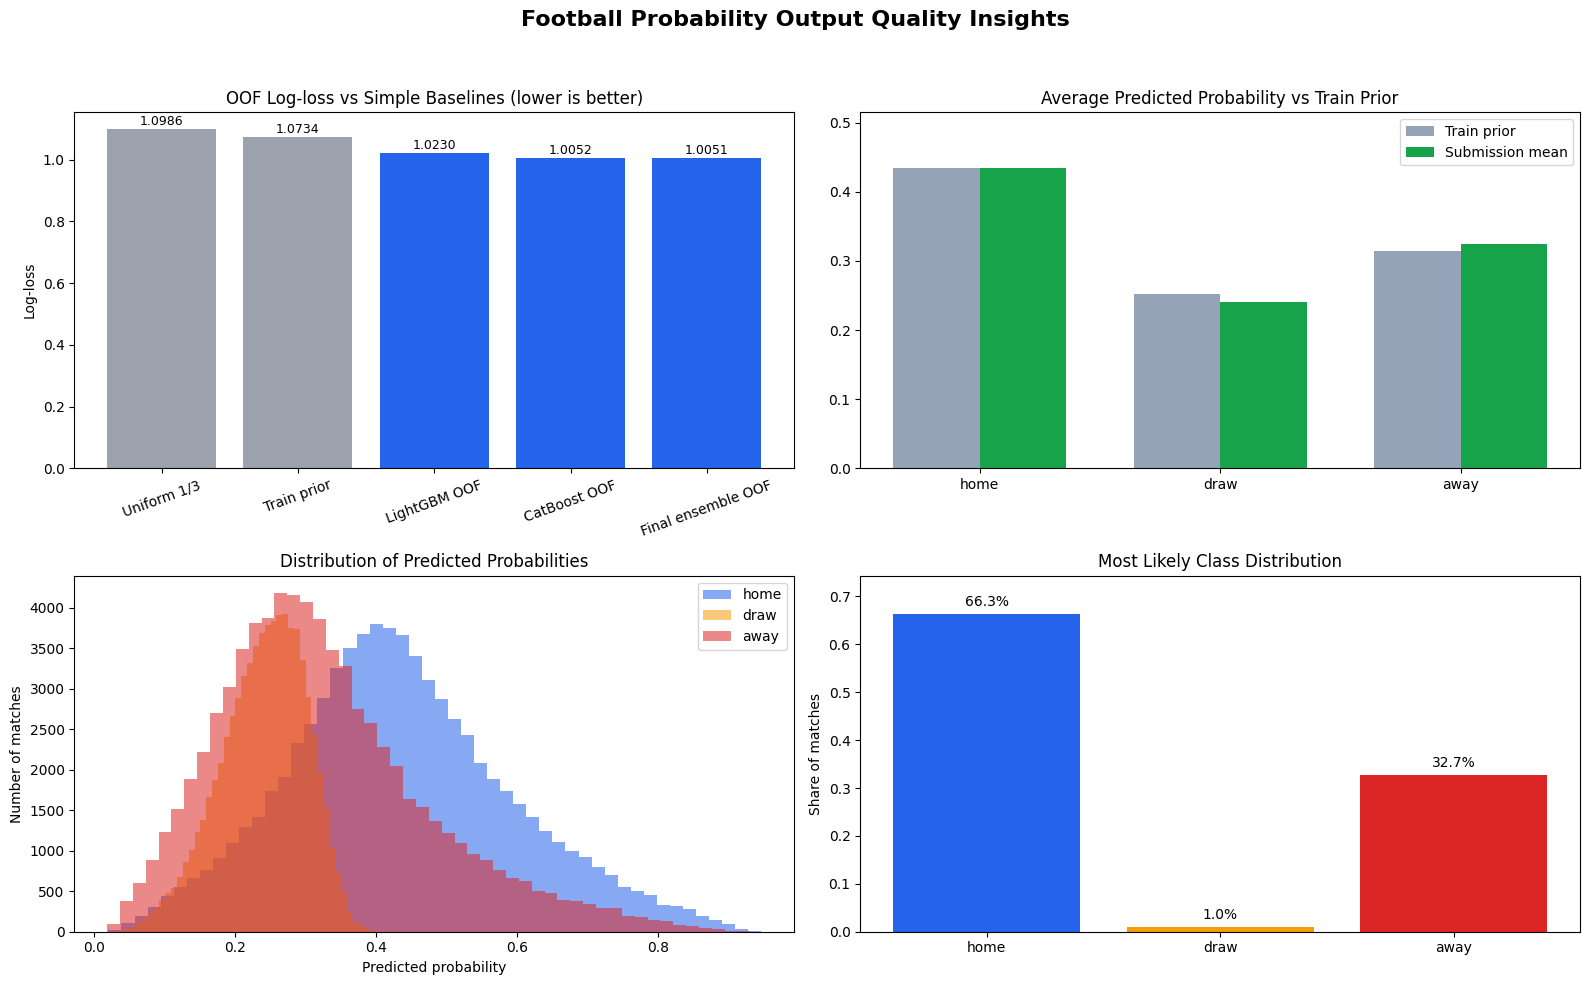

Insight summary
- Best available validation score: Final ensemble OOF with log-loss 1.005114.
- Improvement vs train-prior baseline: 0.068239 absolute, about 6.36% relative.
- Submission mean probabilities: home=0.435, draw=0.240, away=0.325
- Most-likely class distribution: home=66.3%, draw=1.0%, away=32.7%
- A healthy output should beat both baselines, have valid probability sums, and avoid collapsing every match into one class.


In [18]:
import matplotlib.pyplot as plt

assert "train" in globals(), "Run the data loading cell first."
assert "y" in globals(), "Run the target mapping cell first."

submission_for_insight = pd.read_csv(SUBMISSION_PATH) if SUBMISSION_PATH.exists() else submission.copy()
submission_probs = submission_for_insight[["home", "draw", "away"]].to_numpy(dtype="float64")
validate_submission(submission_for_insight, output_example)

train_prior = train["target"].value_counts(normalize=True).reindex(CLASS_ORDER).to_numpy(dtype="float64")
uniform_prior = np.ones(len(CLASS_ORDER), dtype="float64") / len(CLASS_ORDER)

def constant_log_loss(y_true, class_probs):
    class_probs = np.asarray(class_probs, dtype="float64")
    class_probs = np.clip(class_probs, EPS, 1.0)
    return -np.log(class_probs[np.asarray(y_true)]).mean()

baseline_scores = {
    "Uniform 1/3": constant_log_loss(y, uniform_prior),
    "Train prior": constant_log_loss(y, train_prior),
}

if "oof_lgb" in globals():
    baseline_scores["LightGBM OOF"] = log_loss(y, normalize_probabilities(oof_lgb), labels=[0, 1, 2])

oof_cat_for_insight = globals().get("oof_cat", None)
if oof_cat_for_insight is not None:
    baseline_scores["CatBoost OOF"] = log_loss(y, normalize_probabilities(oof_cat_for_insight), labels=[0, 1, 2])

if "final_oof_pred" in globals():
    baseline_scores["Final ensemble OOF"] = log_loss(y, normalize_probabilities(final_oof_pred), labels=[0, 1, 2])

score_df = pd.DataFrame({"model": list(baseline_scores.keys()), "log_loss": list(baseline_scores.values())})
score_df["improvement_vs_train_prior"] = baseline_scores["Train prior"] - score_df["log_loss"]
display(score_df)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Football Probability Output Quality Insights", fontsize=16, fontweight="bold")

# 1) Baseline vs model log-loss. Lower is better.
colors = ["#9ca3af" if "OOF" not in name else "#2563eb" for name in score_df["model"]]
axes[0, 0].bar(score_df["model"], score_df["log_loss"], color=colors)
axes[0, 0].set_title("OOF Log-loss vs Simple Baselines (lower is better)")
axes[0, 0].set_ylabel("Log-loss")
axes[0, 0].tick_params(axis="x", rotation=20)
for idx, value in enumerate(score_df["log_loss"]):
    axes[0, 0].text(idx, value + 0.003, f"{value:.4f}", ha="center", va="bottom", fontsize=9)

# 2) Mean predicted probabilities vs train class prior.
mean_pred = submission_for_insight[CLASS_ORDER].mean().reindex(CLASS_ORDER)
prior_series = pd.Series(train_prior, index=CLASS_ORDER)
x = np.arange(len(CLASS_ORDER))
width = 0.36
axes[0, 1].bar(x - width / 2, prior_series.values, width, label="Train prior", color="#94a3b8")
axes[0, 1].bar(x + width / 2, mean_pred.values, width, label="Submission mean", color="#16a34a")
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(CLASS_ORDER)
axes[0, 1].set_ylim(0, max(prior_series.max(), mean_pred.max()) + 0.08)
axes[0, 1].set_title("Average Predicted Probability vs Train Prior")
axes[0, 1].legend()

# 3) Probability distribution per class.
for cls, color in zip(CLASS_ORDER, ["#2563eb", "#f59e0b", "#dc2626"]):
    axes[1, 0].hist(submission_for_insight[cls], bins=50, alpha=0.55, label=cls, color=color)
axes[1, 0].set_title("Distribution of Predicted Probabilities")
axes[1, 0].set_xlabel("Predicted probability")
axes[1, 0].set_ylabel("Number of matches")
axes[1, 0].legend()

# 4) Most likely class distribution.
argmax_labels = pd.Series(np.array(CLASS_ORDER)[submission_probs.argmax(axis=1)], name="predicted_winner")
argmax_rate = argmax_labels.value_counts(normalize=True).reindex(CLASS_ORDER).fillna(0.0)
axes[1, 1].bar(argmax_rate.index, argmax_rate.values, color=["#2563eb", "#f59e0b", "#dc2626"])
axes[1, 1].set_title("Most Likely Class Distribution")
axes[1, 1].set_ylabel("Share of matches")
axes[1, 1].set_ylim(0, max(argmax_rate.max() + 0.08, 0.2))
for idx, value in enumerate(argmax_rate.values):
    axes[1, 1].text(idx, value + 0.01, f"{100 * value:.1f}%", ha="center", va="bottom")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

best_model_name = score_df.sort_values("log_loss").iloc[0]["model"]
best_model_loss = score_df.sort_values("log_loss").iloc[0]["log_loss"]
prior_loss = baseline_scores["Train prior"]
relative_gain = (prior_loss - best_model_loss) / prior_loss * 100

print("Insight summary")
print(f"- Best available validation score: {best_model_name} with log-loss {best_model_loss:.6f}.")
print(f"- Improvement vs train-prior baseline: {prior_loss - best_model_loss:.6f} absolute, about {relative_gain:.2f}% relative.")
print(f"- Submission mean probabilities: " + ", ".join(f"{cls}={mean_pred[cls]:.3f}" for cls in CLASS_ORDER))
print(f"- Most-likely class distribution: " + ", ".join(f"{cls}={100 * argmax_rate[cls]:.1f}%" for cls in CLASS_ORDER))
print("- A healthy output should beat both baselines, have valid probability sums, and avoid collapsing every match into one class.")
